In [1]:
import pandas as pd

data =  pd.read_csv("Fifa.csv")
data = data.drop("Name" , axis = 1)
data = data.drop("Country" , axis = 1)

data.head()


,Position,Age,Overall_Rating,Future Potential,Team,Value Per M$,Total_Stats Score
0,LW,30,68,68,Ittihad Alexandria,0.65,1660
1,GK,35,67,67,Ittihad Alexandria,0.35,1620
2,GK,28,63,65,Ittihad Alexandria,0.20,1480
3,CB,32,68,68,Ittihad Alexandria,0.50,1695
4,CB,30,66,66,Ittihad Alexandria,0.40,1640


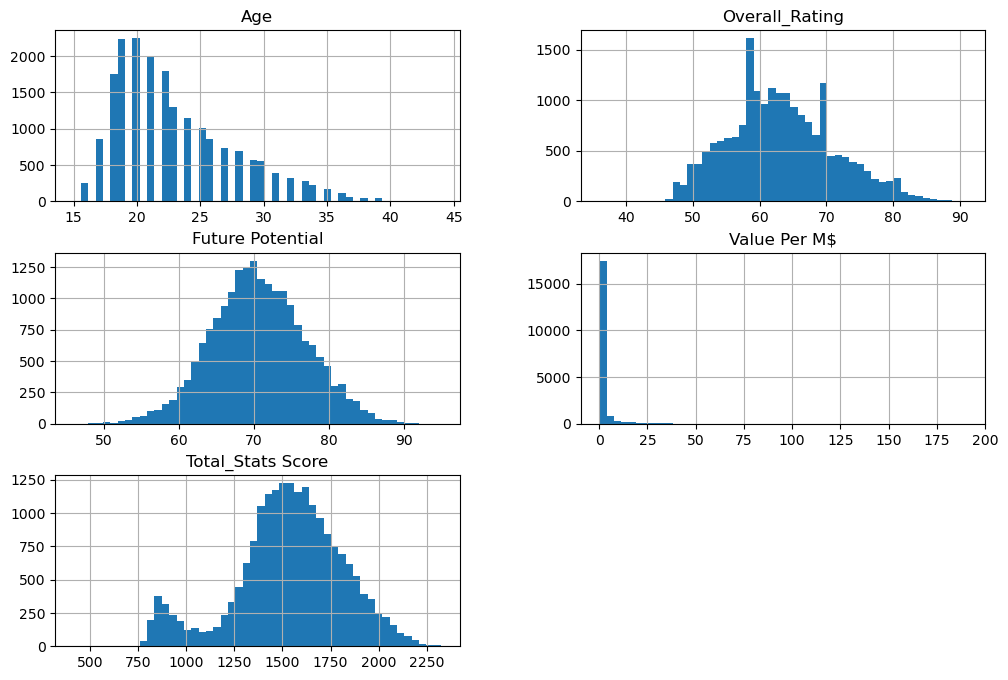

In [2]:
import matplotlib.pyplot as plt

data.hist(bins=50 , figsize=(12,8))

plt.show()

In [3]:
data["Position"].value_counts()

Position
CB     2981
ST     2697
CM     2507
GK     2124
CDM    1358
LM     1279
RM     1203
RB     1100
CAM    1099
LB     1073
RW      707
LW      659
LWB     300
RWB     297
CF      280
RF        2
SW        1
Name: count, dtype: int64

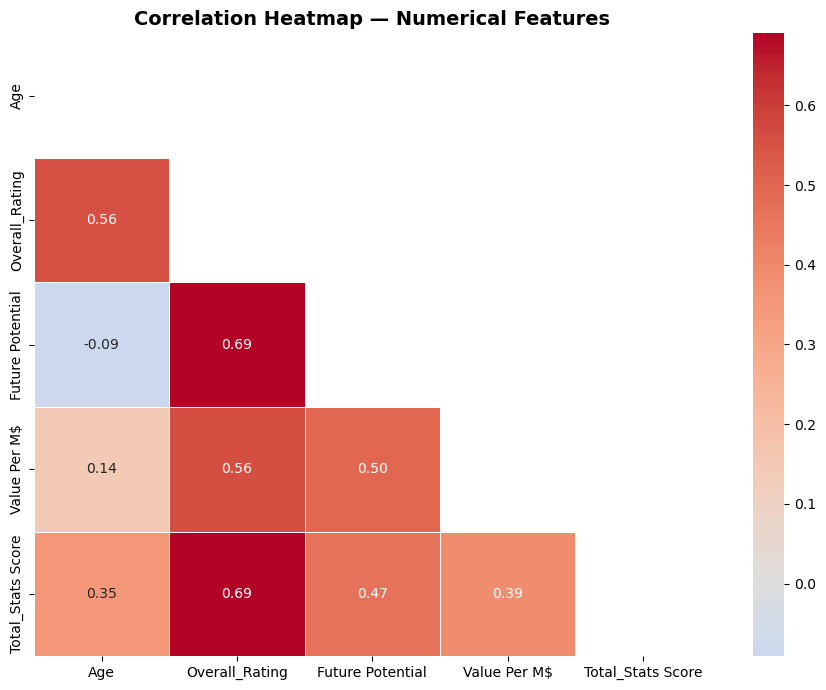

In [4]:
import seaborn as sns
import numpy as np


corr =  data.corr(numeric_only=True)   # colletion heat map between data

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))   # show lower triangle only
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 10}
)
plt.title('Correlation Heatmap — Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

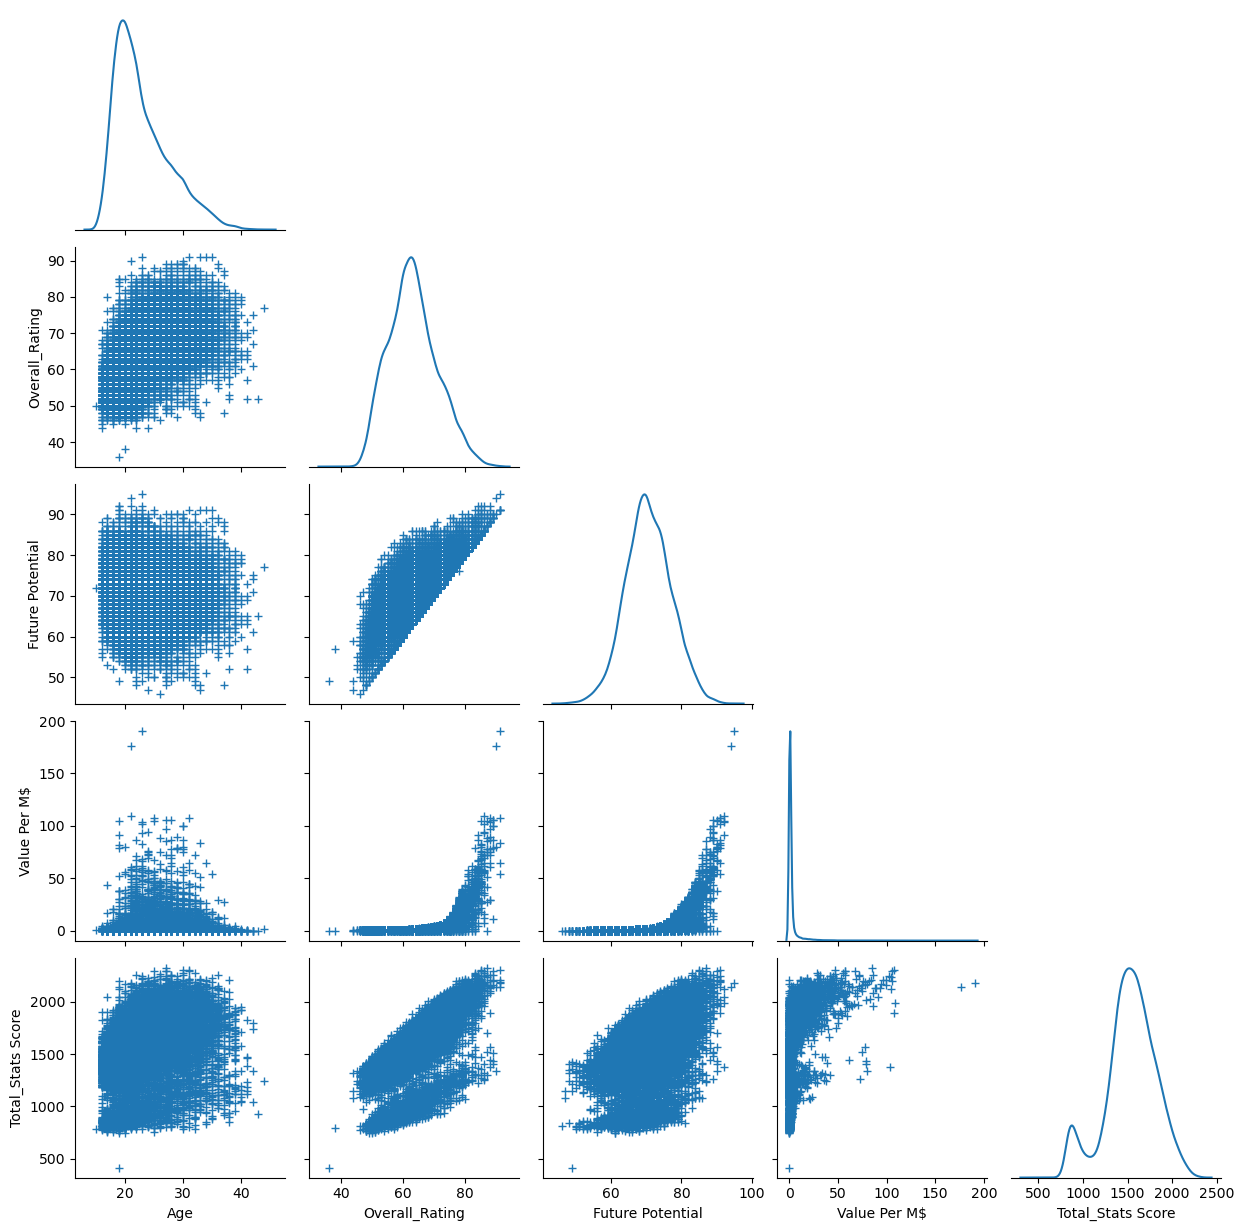

In [5]:
sns.pairplot(
    data,          # categorical variable for color        # nice color palette
    diag_kind="kde",       # smoother diagonal plots
    height=2.5,            # bigger plots
    corner = True , # transparency ,
    plot_kws=dict(marker="+", linewidth=1),
    diag_kws=dict(fill=False)
)

plt.show()

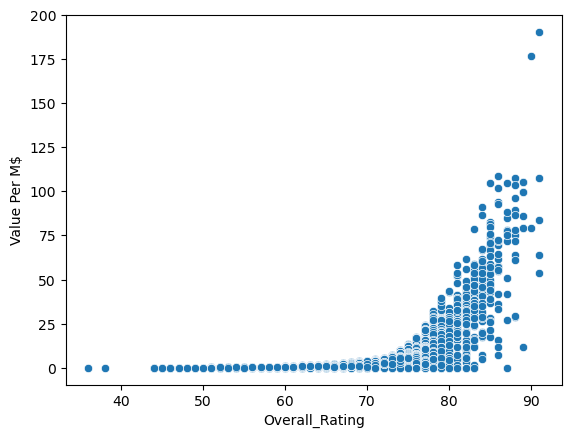

In [6]:
sns.scatterplot(data , x= "Overall_Rating" , y = "Value Per M$")

plt.show()

splitted the rating to 4 cat because its the most normally distributted

In [7]:
data = data.copy()

data.loc[:, "Rating_cat"] = pd.qcut(
    data["Overall_Rating"],
    q=4,
    labels=["weak" , "moderate" , "good" , "verygood"]
)




In [8]:
data["Rating_cat"].value_counts()

Rating_cat
weak        5568
moderate    5102
verygood    4700
good        4297
Name: count, dtype: int64

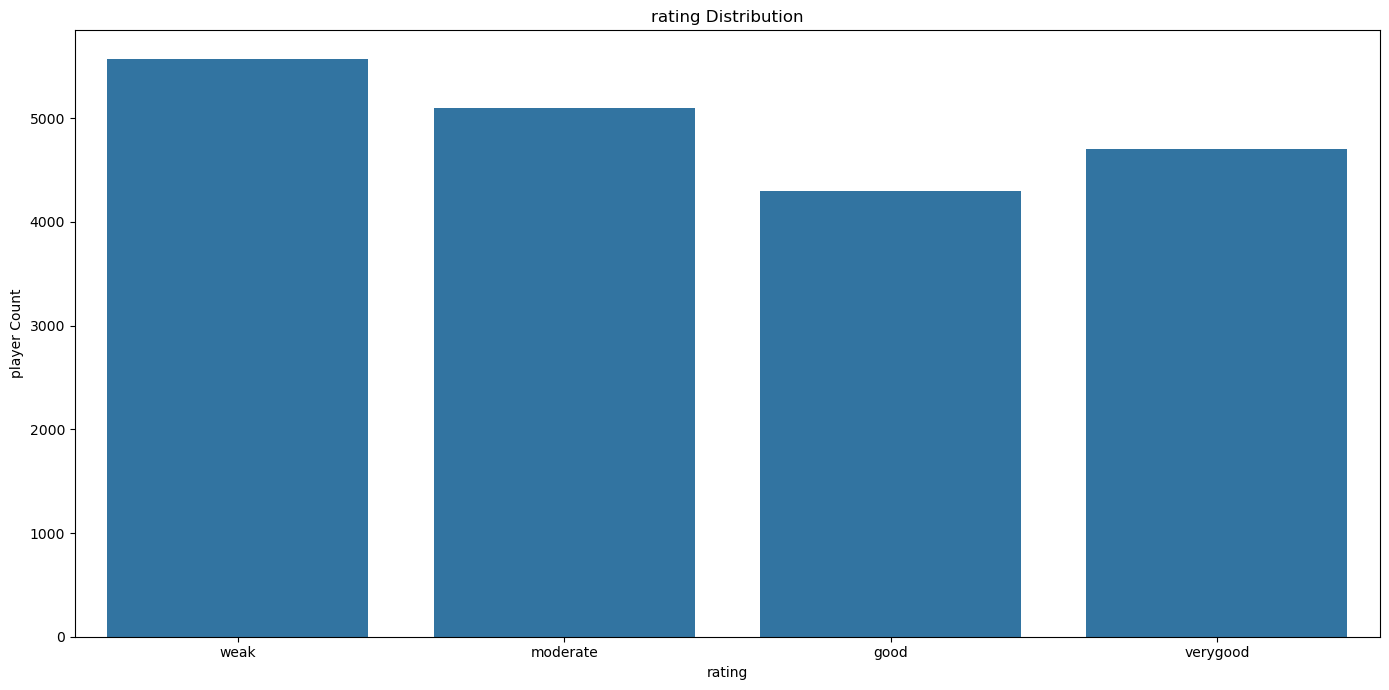

In [9]:
fig, ax = plt.subplots(figsize=(14, 7))
rating_counts = data["Rating_cat"].value_counts().sort_values(ascending=False)
sns.barplot(x=rating_counts.index, y=rating_counts.values, ax=ax )
ax.set_title("rating Distribution")
ax.set_xlabel("rating")
ax.set_ylabel("player Count")
ax.tick_params(axis="x")
plt.tight_layout()
plt.show()

transformer to handle outliers


In [10]:
from sklearn.base import BaseEstimator , TransformerMixin

class Outlier(BaseEstimator, TransformerMixin):   # outliear customer transformer
    def __init__(self, factor=1.5):
        self.factor = factor
        self.lower_bounds_ = None
        self.upper_bounds_ = None

    def fit(self, x , y=None):

        if isinstance(x, pd.DataFrame):        # check if its a dataframe
            x_numeric = x.select_dtypes(include=[np.number])
            Q1 = x_numeric.quantile(0.25)
            Q3 = x_numeric.quantile(0.75)
            IQR = Q3 - Q1
            self.lower_bounds_ = Q1 - self.factor * IQR
            self.upper_bounds_ = Q3 + self.factor * IQR
        else:                                  #check if its a numpy array

            Q1 = np.percentile(x, 25, axis=0)
            Q3 = np.percentile(x, 75, axis=0)
            IQR = Q3 - Q1
            self.lower_bounds_ = Q1 - self.factor * IQR
            self.upper_bounds_ = Q3 + self.factor * IQR
        return self

    def transform(self, x):

        if isinstance(x, pd.DataFrame):
            x_out = x.copy()
            numeric_cols = self.lower_bounds_.index

            x_out[numeric_cols] = x[numeric_cols].clip(
                lower=self.lower_bounds_, upper=self.upper_bounds_, axis=1
            )
            return x_out
        else:
            lower = self.lower_bounds_.values if hasattr(self.lower_bounds_, 'values') else self.lower_bounds_
            upper = self.upper_bounds_.values if hasattr(self.upper_bounds_, 'values') else self.upper_bounds_
            return np.clip(x, lower, upper)

    def get_feature_names_out(self, input_features=None):
        return input_features

In [11]:
from sklearn.model_selection import train_test_split
import random

data = data.sample(frac=1).reset_index(drop=True)

train , test = train_test_split(data , train_size=0.8 , random_state = 42)



In [12]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler ,OneHotEncoder , FunctionTransformer , OrdinalEncoder



num_att = ["Age" , "Overall_Rating" , "Future Potential" , "Total_Stats Score"]   # numeric att

log_att = ["Value Per M$"]   # logged attribute

cat_att = ["Position" , "Team"]   # using onehot encoder

cat_att2 = ["Rating_cat"]      # using ordinalencoder


log_pipeline = FunctionTransformer(np.log1p , inverse_func=np.expm1 , feature_names_out="one-to-one") # logging attributes with right tail to become more of a normal distribution


num_pipeline = Pipeline([
              ("impute" , SimpleImputer(strategy="median")) ,
              ("outlier" , Outlier()),
              ("standardize" , MinMaxScaler(feature_range=(-1 , 1)))  # created a pipeline for the numerical data transformations (handeling nulls and scaling)
])

cat_pipeline = Pipeline([
    ("strimputer" , SimpleImputer(strategy="most_frequent")),
    ("onehot" , OneHotEncoder(handle_unknown="ignore"))
])

cat_pipeline2 = Pipeline([("strimputer2" , OrdinalEncoder())])




In [13]:
from sklearn.compose import make_column_transformer


x_preproccesing = make_column_transformer(
    (num_pipeline , num_att) ,
    (cat_pipeline , cat_att) ,
    (cat_pipeline2 , cat_att2)
)



In [14]:

# train variabels
x_train = train.drop("Value Per M$" , axis = 1)
y_train = train["Value Per M$"]


# test variables
x_test = test.drop(columns=["Value Per M$"])
y_test = test["Value Per M$"]

# x var after preprocessing
x_train = x_preproccesing.fit_transform(x_train)
x_test = x_preproccesing.transform(x_test)

# y var after preprocessing

y_train_log = log_pipeline.fit_transform(y_train.values.reshape(-1 , 1)).ravel()
y_test_log = log_pipeline.transform(y_test.values.reshape(-1,1)).ravel()


In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import learning_curve

lin_reg = LinearRegression()

lin_reg.fit(x_train , y_train_log)



,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Normal linear_reg

In [16]:
from sklearn.metrics import mean_squared_error , r2_score ,mean_absolute_error

# Predictions
y_train_pred_log = lin_reg.predict(x_train)
y_test_pred_log  = lin_reg.predict(x_test)

# Invert log
y_train_pred = log_pipeline.inverse_transform(y_train_pred_log.reshape(-1,1)).ravel()
y_test_pred  = log_pipeline.inverse_transform(y_test_pred_log.reshape(-1,1)).ravel()

# Metrics
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
mae_test  = mean_absolute_error(y_test, y_test_pred)
r2        = r2_score(y_test, y_test_pred)


print(f"Train MSE: {mse_train:.4f}")
print(f"Test MSE: {mse_test:.4f} | RMSE: {rmse_test:.4f} | MAE: {mae_test:.4f}")
print(f"R² score on test set: {r2:.4f}")


Train MSE: 18.4336
Test MSE: 18.7452 | RMSE: 4.3296 | MAE: 1.0102
R² score on test set: 0.6427


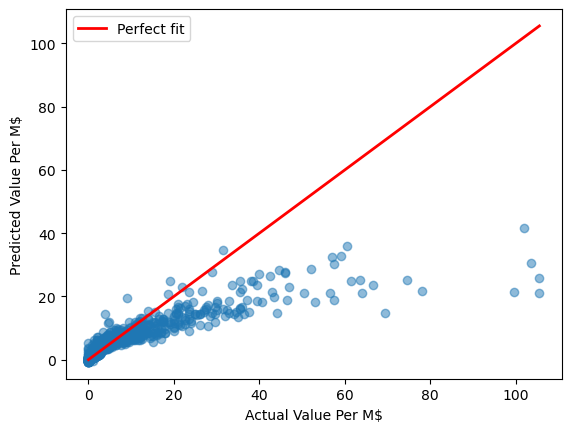

In [17]:

plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red", linewidth=2, label="Perfect fit")
plt.xlabel("Actual Value Per M$")
plt.ylabel("Predicted Value Per M$")
plt.legend()
plt.show()


Using cross Val

In [18]:
from sklearn.model_selection import cross_val_score

# Cross-validation RMSE
lin_rmse = -cross_val_score(
    lin_reg,
    x_train,
    y_train_log,
    scoring="neg_root_mean_squared_error",
    cv=10
)

print("Cross-validation RMSE scores:", lin_rmse)
print("Mean RMSE:", np.mean(lin_rmse))

Cross-validation RMSE scores: [0.25689763 0.26531484 0.25949009 0.26509992 0.25156377 0.26181216
 0.26836548 0.27930919 0.2669611  0.26177908]
Mean RMSE: 0.26365932735226616


model is consistant across fold but need improvment since the r2 is aprox 66%

polynomial features

In [19]:
from sklearn.preprocessing import PolynomialFeatures

poly_features = PolynomialFeatures(degree= 2 , include_bias=False)
x_poly_train= poly_features.fit_transform(x_train)
x_poly_test = poly_features.transform(x_test)

lin_reg.fit(x_poly_train, y_train_log)

y_train_pred_log = lin_reg.predict(x_poly_train)
y_test_pred_log  = lin_reg.predict(x_poly_test)

# Invert to original scale
y_train_pred = np.expm1(y_train_pred_log)
y_test_pred  = np.expm1(y_test_pred_log)

# Evaluate on original scale
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)
r2        = r2_score(y_test, y_test_pred)

print(f"Degree 2 : R²={r2:.4f}, Train MSE={mse_train:.4f}, Test MSE={mse_test:.4f}")

Degree 2 : R²=0.8034, Train MSE=1.4472, Test MSE=10.3135


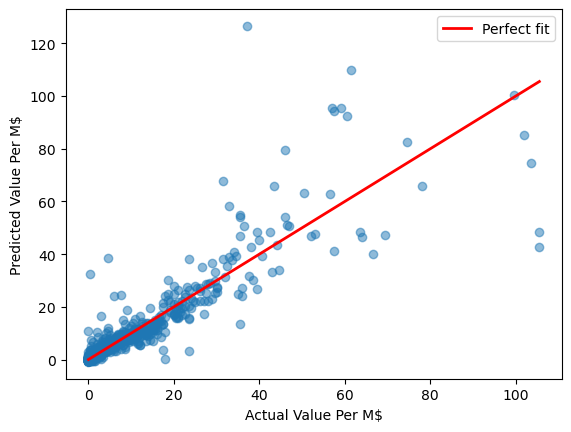

In [20]:

plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red", linewidth=2, label="Perfect fit")
plt.xlabel("Actual Value Per M$")
plt.ylabel("Predicted Value Per M$")
plt.legend()
plt.show()


Ridge regression

In [21]:
from sklearn.linear_model import Ridge

alphas = [0.01, 0.1, 1, 10]
r2_scores_l2 = []   # list of r2 scores corresponding to the alpha
mse_scores_l2 = []  # list of mse scores based on the alphas
best_l2_alpha = 0
currentr2 = 0


for alpha in alphas:

    # ridge regression model
    ridge_reg = Ridge(alpha=alpha)
    ridge_reg.fit(x_poly_train, y_train_log)
    y_test_pred = np.expm1(ridge_reg.predict(x_poly_test))

    # r2 of current alpha
    r2 = r2_score(y_test, y_test_pred)
    r2_scores_l2.append(r2)

    if r2 > currentr2 :
        currentr2 = r2
        best_l2_alpha = alpha


    # mse score of current alpha
    mse = mean_squared_error(y_test, y_test_pred)
    mse_scores_l2.append(mse)
    print(f"alpha={alpha}, R²={r2:.4f}, Test MSE={mse:.4f}")
 

alpha=0.01, R²=0.8434, Test MSE=8.2149
alpha=0.1, R²=0.8759, Test MSE=6.5112
alpha=1, R²=0.8925, Test MSE=5.6407
alpha=10, R²=0.8954, Test MSE=5.4861


In [22]:
ridge_reg = Ridge(alpha = best_l2_alpha)

ridge_reg.fit(x_poly_train , y_train_log)

y_train_pred_log = ridge_reg.predict(x_poly_train)
y_test_pred_log  = ridge_reg.predict(x_poly_test)

# Invert to original scale
y_train_pred = np.expm1(y_train_pred_log)
y_test_pred  = np.expm1(y_test_pred_log)

# Evaluate on original scale
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)
r2        = r2_score(y_test, y_test_pred)

print(f"Degree 2 : R²={r2:.4f}, Train MSE={mse_train:.4f}, Test MSE={mse_test:.4f}")


Degree 2 : R²=0.8954, Train MSE=4.1462, Test MSE=5.4861


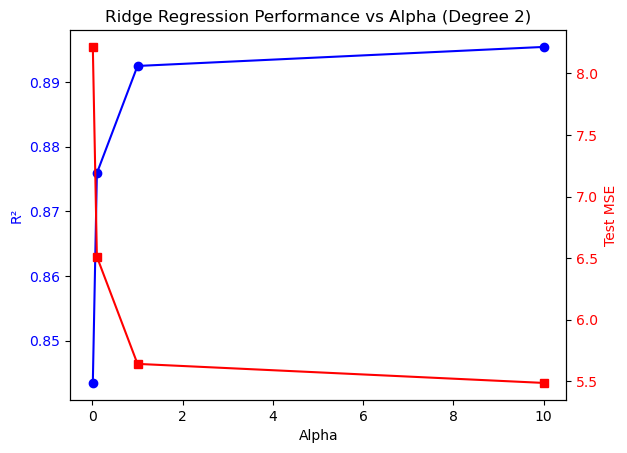

In [23]:
fig, ax1 = plt.subplots()

ax1.plot(alphas, r2_scores_l2, marker='o', color='blue', label='R²')
ax1.set_xlabel("Alpha")
ax1.set_ylabel("R²", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.plot(alphas, mse_scores_l2, marker='s', color='red', label='Test MSE')
ax2.set_ylabel("Test MSE", color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title("Ridge Regression Performance vs Alpha (Degree 2)")
plt.show()

Lasso regression

In [24]:
from sklearn.linear_model import Lasso


alphas = [0.001, 0.01, 0.1, 1]
r2_scores_l1 = []   # list of r2 scores corresponding to the alpha
mse_scores_l1 = []  # list of mse scores based on the alphas
best_l1_alpha = 0.001
currentr2 = 0


for alpha in alphas:

    # ridge regression model
    ridge_reg = Lasso(alpha=alpha,max_iter=1000)
    ridge_reg.fit(x_poly_train, y_train_log)
    y_test_pred = np.expm1(ridge_reg.predict(x_poly_test))

    # r2 of current alpha
    r2 = r2_score(y_test, y_test_pred)
    r2_scores_l1.append(r2)

    if r2 > currentr2 :
        currentr2 = r2
        best_l2_alpha = alpha


    # mse score of current alpha
    mse = mean_squared_error(y_test, y_test_pred)
    mse_scores_l1.append(mse)
    print(f"alpha={alpha}, R²={r2:.4f}, Test MSE={mse:.4f}")



alpha=0.001, R²=0.8715, Test MSE=6.7414
alpha=0.01, R²=0.7647, Test MSE=12.3477
alpha=0.1, R²=0.2194, Test MSE=40.9585
alpha=1, R²=-0.0344, Test MSE=54.2747


In [25]:
lasso_reg = Lasso(alpha = best_l1_alpha)

lasso_reg.fit(x_poly_train , y_train_log)

y_train_pred_log = lasso_reg.predict(x_poly_train)
y_test_pred_log  = lasso_reg.predict(x_poly_test)

# Invert to original scale
y_train_pred = np.expm1(y_train_pred_log)
y_test_pred  = np.expm1(y_test_pred_log)

# Evaluate on original scale
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)
r2        = r2_score(y_test, y_test_pred)

print(f"Degree 2 : R²={r2:.4f}, Train MSE={mse_train:.4f}, Test MSE={mse_test:.4f}")


Degree 2 : R²=0.8715, Train MSE=6.7345, Test MSE=6.7414


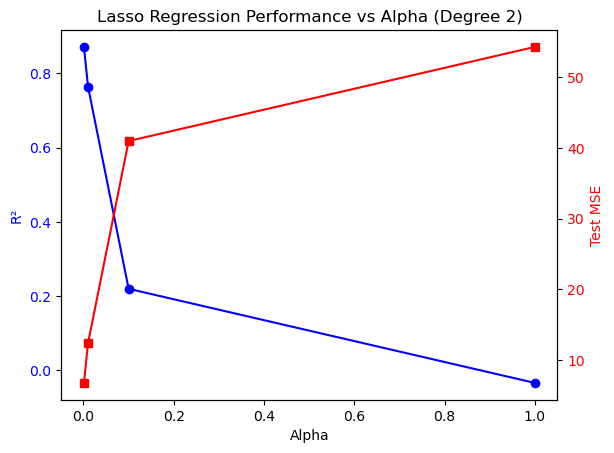

In [26]:
fig, ax1 = plt.subplots()

ax1.plot(alphas, r2_scores_l1, marker='o', color='blue', label='R²')
ax1.set_xlabel("Alpha")
ax1.set_ylabel("R²", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.plot(alphas, mse_scores_l1, marker='s', color='red', label='Test MSE')
ax2.set_ylabel("Test MSE", color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title("Lasso Regression Performance vs Alpha (Degree 2)")
plt.show()

#5.logistic regression

In [27]:
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix


We rebuild X without Overall_Rating because it was used to create the target labels, so including it would be cheating


In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Select features — everything except Overall_Rating and Value
#encoding position & team cuz they are txt features (scaler cant handle)
X = pd.get_dummies(data[["Age", "Future Potential", "Total_Stats Score", "Position", "Team"]])
y = data["Rating_cat"]

#split 80/20
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2 , random_state=42)


#scaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)




Train a baseline Logistic Regression model with default settings.

In [29]:
log_model = LogisticRegression(max_iter=1000,random_state=42)
log_model.fit(x_train_scaled, y_train)

y_pred = log_model.predict(x_test_scaled)

Evaluate using: Accuracy, Precision, Recall, F1-score for each class.

In [30]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average="weighted")
rec = recall_score(y_test, y_pred, average="weighted")
f1s = f1_score(y_test, y_pred, average="weighted")



print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1s:.4f}")

Accuracy:  0.7936
Precision: 0.7937
Recall:    0.7936
F1-Score:  0.7936


full classifiacation report


In [31]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred,
                            target_names = ["weak", "moderate", "good", "verygood"]))

              precision    recall  f1-score   support

        weak       0.68      0.67      0.68       833
    moderate       0.72      0.72      0.72      1037
        good       0.88      0.87      0.87       938
    verygood       0.88      0.89      0.88      1126

    accuracy                           0.79      3934
   macro avg       0.79      0.79      0.79      3934
weighted avg       0.79      0.79      0.79      3934



confusion matrix heatmap


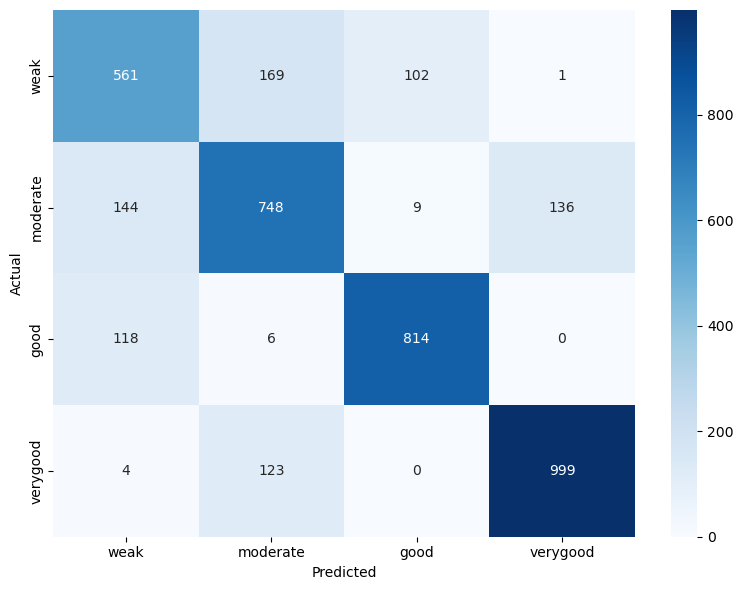

In [32]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm,
            annot=True,
            fmt='g',
            cmap = 'Blues',
            xticklabels=["weak", "moderate", "good", "verygood"],
            yticklabels=["weak", "moderate", "good", "verygood"])
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

sweep c values

In [33]:
import numpy as np
c_values = np.logspace(-3, 3, 20 ) # 2o numbers from 0.001 to 1000

train_acc = []
test_acc = []


for c in c_values:
  model = LogisticRegression(C=c , max_iter=1000 , random_state=42 ,penalty="l2",solver="lbfgs")
  model.fit(x_train_scaled, y_train)
  train_acc.append(model.score(x_train_scaled, y_train))
  test_acc.append(model.score(x_test_scaled, y_test))









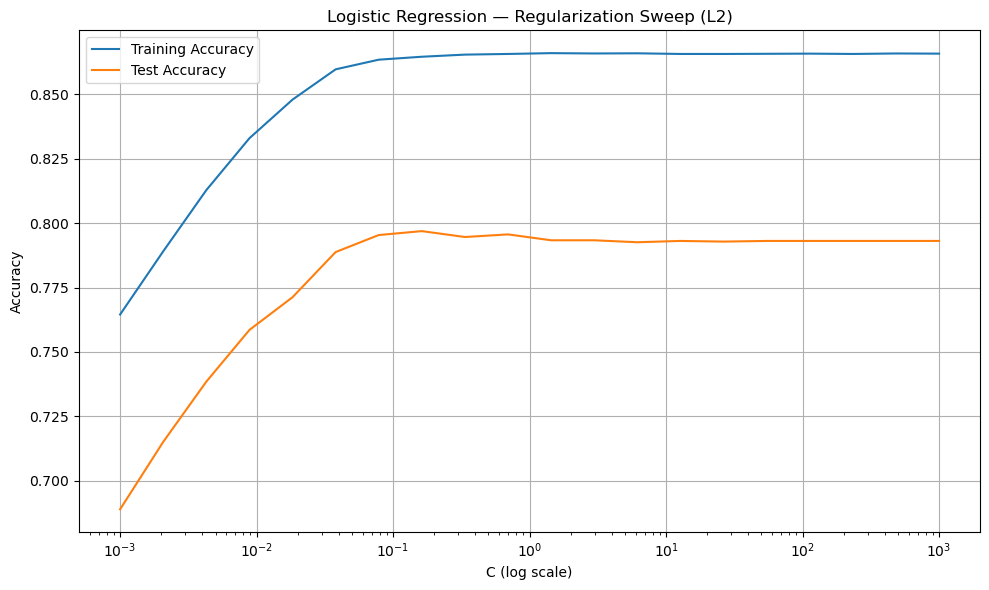

Best C: 0.1624       Test Accuracy: 0.7969


In [34]:
plt.figure(figsize=(10, 6))
plt.plot(c_values, train_acc, label='Training Accuracy')
plt.plot(c_values, test_acc, label='Test Accuracy')
plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('Accuracy')
plt.title("Logistic Regression — Regularization Sweep (L2)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()




best_c = c_values[np.argmax(test_acc)]
print(f"Best C: {best_c:.4f}       Test Accuracy: {max(test_acc):.4f}")


L1 vs L2 at Best C

In [35]:
model_l2 = LogisticRegression(C=best_c , max_iter=1000 , random_state=42 ,penalty="l2",solver="lbfgs")
model_l2.fit(x_train_scaled, y_train)
acc_l2 = model_l2.score(x_test_scaled, y_test)



model_l1 = LogisticRegression(C=best_c , max_iter=1000 , random_state=42 ,penalty="l1",solver="saga")
model_l1.fit(x_train_scaled, y_train )
acc_l1 = model_l1.score(x_test_scaled, y_test)

print(f"L2 Accuracy: {acc_l2:.4f}")
print(f"L1 Accuracy: {acc_l1:.4f}")
print(f"Best C: {best_c}")
print(f"better: { 'L2' if acc_l2 > acc_l1 else 'L1'}")


L2 Accuracy: 0.7969
L1 Accuracy: 0.8033
Best C: 0.1623776739188721
better: L1


c:\Users\Helal-Store\Downloads\anaconda\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


# 6.Naive Bayes


In [36]:
from sklearn.naive_bayes import GaussianNB, BernoulliNB, ComplementNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, Binarizer

In [37]:
num_cols = ["Age", "Future Potential", "Total_Stats Score"]

X_train_num = train[num_cols]
X_test_num  = test[num_cols]

y_train_clf = train["Rating_cat"]
y_test_clf  = test["Rating_cat"]

tier_labels = ["weak", "moderate", "good", "verygood"]

print(f"Train class distribution: {y_train_clf.value_counts()}\n")
print(f"Test class distribution: {y_test_clf.value_counts()}\n")

Train class distribution: Rating_cat
weak        4442
moderate    4065
verygood    3762
good        3464
Name: count, dtype: int64

Test class distribution: Rating_cat
weak        1126
moderate    1037
verygood     938
good         833
Name: count, dtype: int64



Accuracy: 0.7180986273512964
              precision    recall  f1-score   support

        good       0.62      0.57      0.59       833
    moderate       0.60      0.71      0.65      1037
    verygood       0.84      0.77      0.80       938
        weak       0.81      0.80      0.81      1126

    accuracy                           0.72      3934
   macro avg       0.72      0.71      0.71      3934
weighted avg       0.72      0.72      0.72      3934



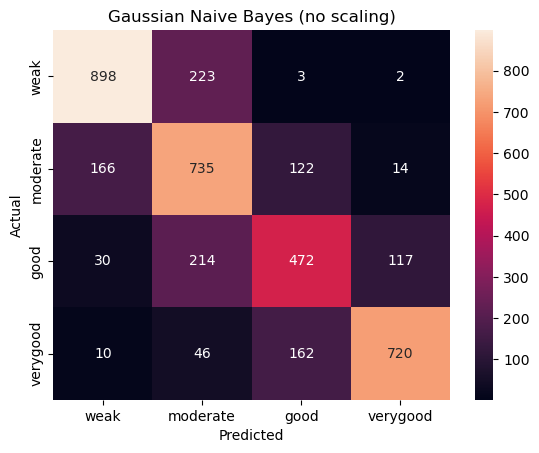

In [38]:
gnb = GaussianNB()
gnb.fit(X_train_num, y_train_clf)
y_pred_gnb = gnb.predict(X_test_num)

print("Accuracy:", accuracy_score(y_test_clf, y_pred_gnb))
print(classification_report(y_test_clf, y_pred_gnb))

cm = confusion_matrix(y_test_clf, y_pred_gnb, labels=tier_labels)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=tier_labels, yticklabels=tier_labels)
plt.title("Gaussian Naive Bayes (no scaling)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Accuracy: 0.7180986273512964
              precision    recall  f1-score   support

        good       0.62      0.57      0.59       833
    moderate       0.60      0.71      0.65      1037
    verygood       0.84      0.77      0.80       938
        weak       0.81      0.80      0.81      1126

    accuracy                           0.72      3934
   macro avg       0.72      0.71      0.71      3934
weighted avg       0.72      0.72      0.72      3934



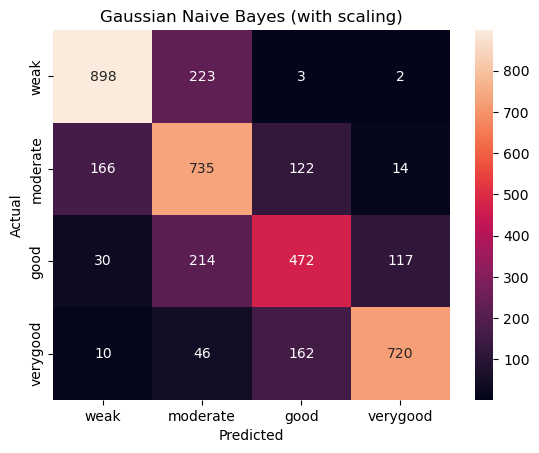

In [39]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_num)
X_test_scaled  = scaler.transform(X_test_num)

gnb_scaling = GaussianNB()
gnb_scaling.fit(X_train_scaled, y_train_clf)
y_pred_gnb_scaling = gnb_scaling.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test_clf, y_pred_gnb_scaling))
print(classification_report(y_test_clf, y_pred_gnb_scaling))

cm2 = confusion_matrix(y_test_clf, y_pred_gnb_scaling, labels=tier_labels)
sns.heatmap(cm2, annot=True, fmt='d', xticklabels=tier_labels, yticklabels=tier_labels)
plt.title("Gaussian Naive Bayes (with scaling)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Scaling didn't have any effect on Gaussian naive bayes bec. it calculates its own mean and variance per clas internally. So the results stay the same


Accuracy: 0.8451957295373665
              precision    recall  f1-score   support

        good       1.00      1.00      1.00       833
    moderate       0.76      0.60      0.67      1037
    verygood       0.90      0.97      0.93       938
        weak       0.75      0.85      0.80      1126

    accuracy                           0.85      3934
   macro avg       0.85      0.86      0.85      3934
weighted avg       0.84      0.85      0.84      3934



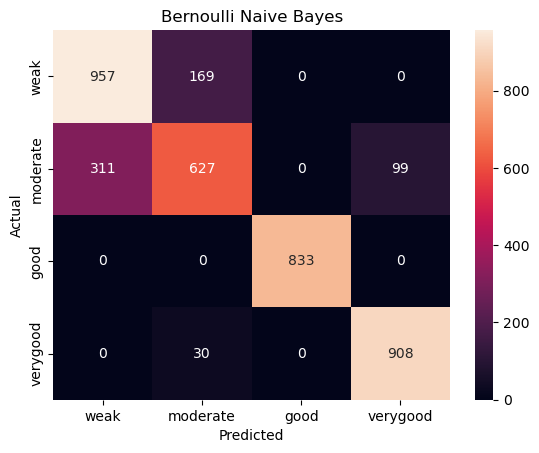

In [40]:
y_train_clf = train["Rating_cat"]
y_test_clf  = test["Rating_cat"]

X_train_bnb = x_preproccesing.transform(train.drop("Value Per M$", axis=1))
X_test_bnb  = x_preproccesing.transform(test.drop("Value Per M$", axis=1))

bnb = BernoulliNB()
bnb.fit(X_train_bnb, y_train_clf)

y_pred_bnb = bnb.predict(X_test_bnb)

print("Accuracy:", accuracy_score(y_test_clf, y_pred_bnb))
print(classification_report(y_test_clf, y_pred_bnb))

tier_labels = ["weak", "moderate", "good", "verygood"]

cm = confusion_matrix(y_test_clf, y_pred_bnb, labels=tier_labels)

sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=tier_labels,
            yticklabels=tier_labels)

plt.title("Bernoulli Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Accuracy: 0.5238942552109812
              precision    recall  f1-score   support

        good       0.41      0.34      0.37       833
    moderate       0.47      0.26      0.33      1037
    verygood       0.56      0.74      0.64       938
        weak       0.58      0.72      0.64      1126

    accuracy                           0.52      3934
   macro avg       0.50      0.52      0.50      3934
weighted avg       0.51      0.52      0.50      3934



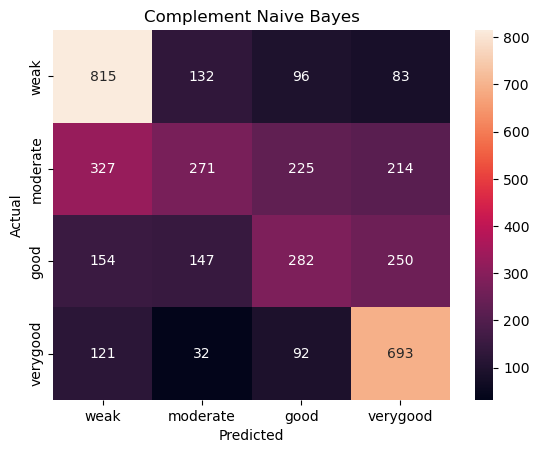

In [42]:
x_train_dense = x_train.values
x_test_dense = x_test.values

x_train_comp = x_train_dense - x_train_dense.min()
x_test_comp = x_test_dense - x_train_dense.min()

cnb = ComplementNB()

cnb.fit(x_train_comp, y_train_clf)

y_pred_cnb = cnb.predict(x_test_comp)

print("Accuracy:", accuracy_score(y_test_clf, y_pred_cnb))
print(classification_report(y_test_clf, y_pred_cnb))

cm4 = confusion_matrix(y_test_clf, y_pred_cnb, labels=tier_labels)

sns.heatmap(
    cm4,
    annot=True,
    fmt='d',
    xticklabels=tier_labels,
    yticklabels=tier_labels
)

plt.title("Complement Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

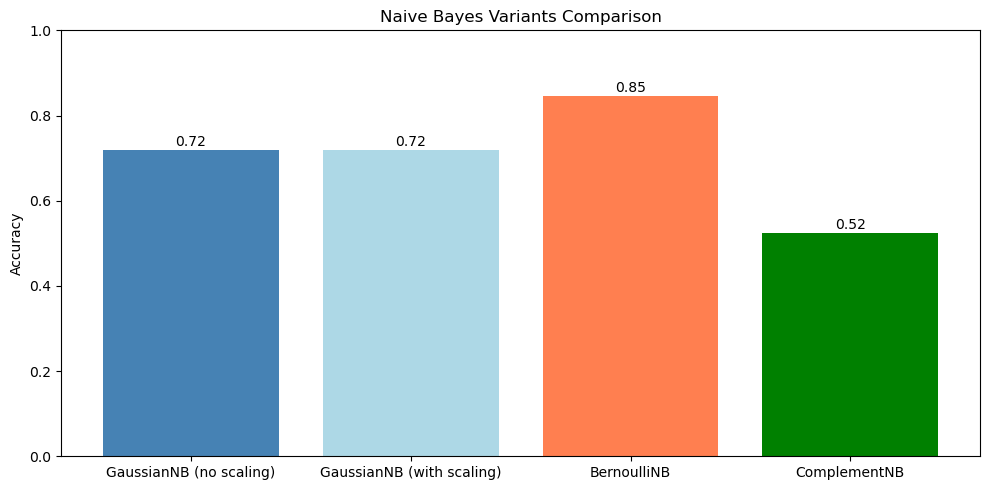

In [43]:
models = ["GaussianNB (no scaling)", "GaussianNB (with scaling)", "BernoulliNB", "ComplementNB"]
accuracies = [
    accuracy_score(y_test_clf, y_pred_gnb),
    accuracy_score(y_test_clf, y_pred_gnb_scaling),
    accuracy_score(y_test_clf, y_pred_bnb),
    accuracy_score(y_test_clf, y_pred_cnb)
]
plt.figure(figsize=(10, 5))
plt.bar(models, accuracies, color=['steelblue', 'lightblue', 'coral', 'green'])
plt.ylabel("Accuracy")
plt.title("Naive Bayes Variants Comparison")
plt.ylim(0, 1)
plt.xticks(rotation=0, ha='center')
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.01, f"{acc:.2f}", ha='center')
plt.tight_layout()
plt.show()

Gaussian is the best naive bayes variant for this data set because most of the features are continous and numerical that matches the Gaussian assumptions while Bernoulli achieves higher accuracy  due to having access to more features in the OHE set it is not the best variant for our dataset

#7.1 K-Fold Cross-Validation (Regression)

In [44]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(ridge_reg # our best model
                            , x_poly_train, y_train_log , cv=5 , scoring="neg_mean_squared_error")

fold_rmse = -cv_scores
print(f"rmse per  fold: {fold_rmse}")
print(f"Mean RMSE: {fold_rmse.mean():.4f}")



rmse per  fold: [0.55803856 0.58121821 0.58188749 0.53042615 0.58968542]
Mean RMSE: 0.5683


<function matplotlib.pyplot.show(close=None, block=None)>

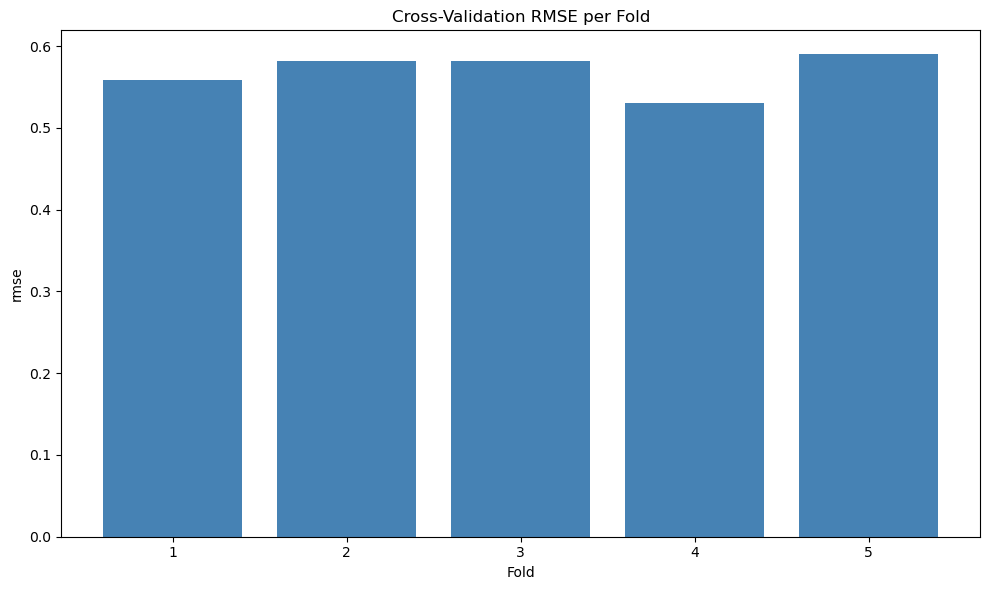

In [45]:
plt.figure(figsize=(10, 6))
plt.bar(range(1, 6), fold_rmse, color='steelblue', label='Fold RMSE')
plt.xlabel("Fold")
plt.ylabel("rmse")
plt.xticks(range(1, 6))
plt.title("Cross-Validation RMSE per Fold")
plt.tight_layout()
plt.show

#7.2  K-Fold (Classification)

In [46]:
from sklearn.model_selection import StratifiedKFold , cross_val_score
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv for logistic regression

In [47]:
cv_scores = cross_val_score(log_model, x_train_scaled, y_train, cv=skf, scoring="accuracy")
print(f" logistic regression Accuracy per fold: {cv_scores}")
print(f"Mean Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")

 logistic regression Accuracy per fold: [0.77724817 0.78265014 0.78265014 0.77876669 0.78194533]
Mean Accuracy: 0.7807
Standard Deviation: 0.0022


cv for gaussian nb

In [48]:
gnb_cv_scores = cross_val_score(
    gnb,
    X_train_num,
    y_train_clf,
    cv=skf,
    scoring = "accuracy"
)

print ("gaussian nb _ accuaracy per fold ",gnb_cv_scores)
print(f"Mean Accuracy: {gnb_cv_scores.mean():.4f}")
print(f"Standard Deviation: {gnb_cv_scores.std():.4f}")

gaussian nb _ accuaracy per fold  [0.71591992 0.72608834 0.70384493 0.71551176 0.71551176]
Mean Accuracy: 0.7154
Standard Deviation: 0.0070


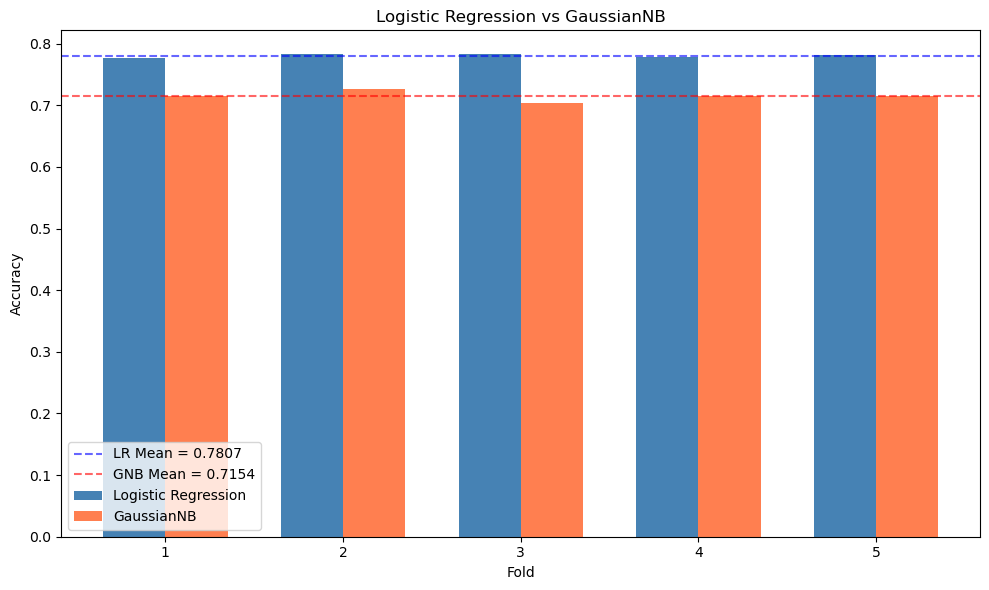

In [49]:
folds = np.arange(1, 6)
bar_width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(folds - bar_width/2, cv_scores,  width=bar_width, label='Logistic Regression', color='steelblue')
plt.bar(folds + bar_width/2, gnb_cv_scores, width=bar_width, label='GaussianNB',          color='coral')

plt.axhline(y=cv_scores.mean(),  color='blue', linestyle='--', alpha=0.6, label=f'LR Mean = {cv_scores.mean():.4f}')
plt.axhline(y=gnb_cv_scores.mean(), color='red',  linestyle='--', alpha=0.6, label=f'GNB Mean = {gnb_cv_scores.mean():.4f}')

plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("Logistic Regression vs GaussianNB")
plt.xticks(folds)
plt.legend()
plt.tight_layout()
plt.show()

In [50]:
print(" Model Comparison ")
print(f"Logistic Regression  Mean: {cv_scores.mean():.4f} | Std: {cv_scores.std():.4f}")
print(f"GaussianNB           Mean: {gnb_cv_scores.mean():.4f} | Std: {gnb_cv_scores.std():.4f}")

better_model    = "Logistic Regression" if cv_scores.mean() > gnb_cv_scores.mean() else "GaussianNB"
more_stable     = "Logistic Regression" if cv_scores.std()  < gnb_cv_scores.std()  else "GaussianNB"

print(f"\nBetter accuracy : {better_model}")
print(f"More stable     : {more_stable}  (lower std = more consistent across folds)")

 Model Comparison 
Logistic Regression  Mean: 0.7807 | Std: 0.0022
GaussianNB           Mean: 0.7154 | Std: 0.0070

Better accuracy : Logistic Regression
More stable     : Logistic Regression  (lower std = more consistent across folds)


## 8.1 Model Comparison

### Which model performed best overall?

**Regression:**  
The best-performing model was **Ridge Regression**, as it achieved the lowest RMSE compared to other models. This indicates better generalization and reduced overfitting due to regularization.

**Classification:**  
The best-performing model was **Logistic Regression**, as it achieved the highest accuracy (or best evaluation metric). It is well-suited for binary classification problems and handles linear decision boundaries effectively.

---

### Is classification easier or harder than regression on this dataset? Why?

Classification appears to be **easier** than regression on this dataset.

This is because classification involves predicting discrete labels (e.g., 0 or 1), which is a simpler task compared to regression, where the model must predict continuous numerical values with high precision. Small errors in regression are penalized more heavily, making it a more challenging task.

---

## 8.2 Regularization Analysis

### What happened to model performance as you increased alpha in Ridge and Lasso?

As the value of alpha increased:

- Model complexity decreased.
- Overfitting was reduced.
- Performance initially improved.
- However, when alpha became too large, the model started to underfit, leading to worse performance.

This shows that there is an optimal alpha value that balances bias and variance.

---

### Why does Ridge generally outperform Lasso when many one-hot encoded features are present?

Ridge Regression generally performs better than Lasso in the presence of many one-hot encoded features because:

- **Ridge (L2 regularization)** shrinks coefficients but does not eliminate them, preserving all features.
- **Lasso (L1 regularization)** performs feature selection by forcing some coefficients to become exactly zero.

In datasets with one-hot encoding, each category is represented as a separate feature. Removing some of these features (as Lasso does) can lead to loss of important information. Therefore, Ridge maintains better performance by keeping all features while reducing their impact.



---

# Assignment 3 Continuation

The original Assignment 2 cells above are preserved unchanged. The following cells complete Assignment 3 in the same notebook as a continuation.


# Assignment 3 - Unified Scouting System

This section continues the Assignment 2 notebook above without changing the original Assignment 2 file. It upgrades the baseline FIFA player models into a unified scouting system that predicts both player market value and performance tier from one raw player profile.


## 0. Project Setup

The notebook keeps technical continuity with Assignment 2 by using the same FIFA dataset and the same two prediction goals: player market value and performance tier.


In [1]:
import json
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, VotingRegressor, VotingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
)
from sklearn.model_selection import (
    GridSearchCV, KFold, StratifiedKFold, train_test_split,
    cross_val_score, learning_curve
)
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.svm import SVR, SVC

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 1. Load Data and Targets

The performance target is recreated from Overall_Rating using quartiles. For classification, Overall_Rating is removed from the features because Rating_cat is derived from it, so keeping it would create leakage.


In [2]:
candidate_paths = [
    Path("Fifa.csv"),
    Path(r"C:\Users\Helal-Store\OneDrive\Desktop\machine learning\Fifa.csv"),
]

for candidate in candidate_paths:
    if candidate.exists():
        DATA_PATH = candidate
        break
else:
    raise FileNotFoundError("Fifa.csv was not found beside this notebook or in the original machine learning folder.")

raw_data = pd.read_csv(DATA_PATH)
data_a3 = raw_data.copy()
for col in ["Name", "Country"]:
    if col in data_a3.columns:
        data_a3 = data_a3.drop(columns=col)

data_a3["Rating_cat"] = pd.qcut(
    data_a3["Overall_Rating"],
    q=4,
    labels=["weak", "moderate", "good", "verygood"],
)

print(f"Loaded: {DATA_PATH}")
print("Shape:", data_a3.shape)
data_a3.head()


Loaded: Fifa.csv
Shape: (19667, 8)


,Position,Age,Overall_Rating,Future Potential,Team,Value Per M$,Total_Stats Score,Rating_cat
0,LW,30,68,68,Ittihad Alexandria,0.65,1660,good
1,GK,35,67,67,Ittihad Alexandria,0.35,1620,good
2,GK,28,63,65,Ittihad Alexandria,0.20,1480,moderate
3,CB,32,68,68,Ittihad Alexandria,0.50,1695,good
4,CB,30,66,66,Ittihad Alexandria,0.40,1640,good


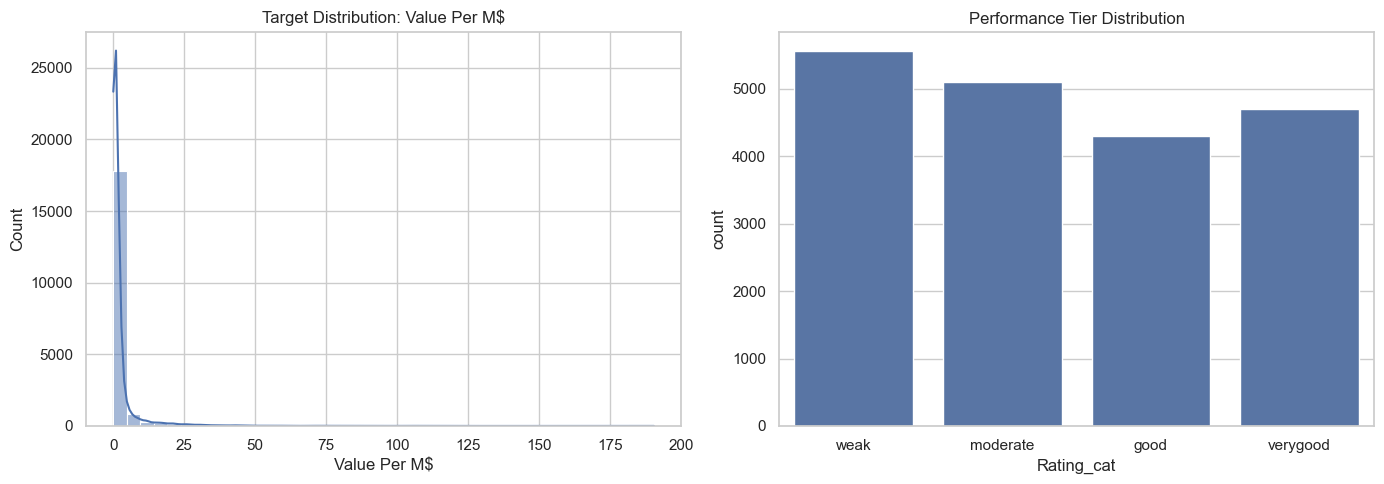

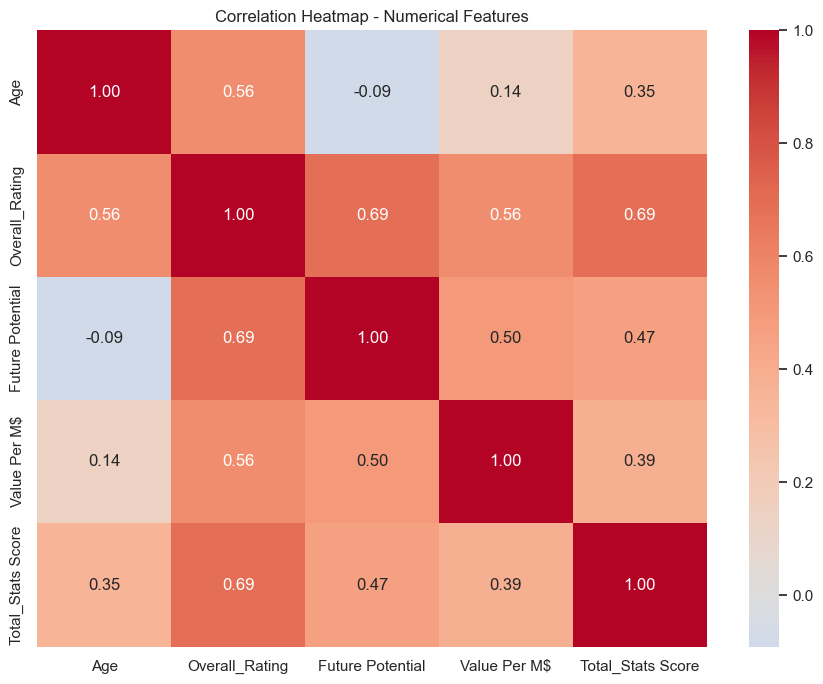

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data_a3["Value Per M$"], bins=40, kde=True, ax=axes[0])
axes[0].set_title("Target Distribution: Value Per M$")
sns.countplot(data=data_a3, x="Rating_cat", order=["weak", "moderate", "good", "verygood"], ax=axes[1])
axes[1].set_title("Performance Tier Distribution")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 7))
sns.heatmap(data_a3.corr(numeric_only=True), cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Correlation Heatmap - Numerical Features")
plt.tight_layout()
plt.show()


## 2. Baseline Recap

Assignment 2 used linear and probabilistic baselines. Here, Ridge Regression and Logistic Regression are rebuilt inside clean pipelines so the advanced system can be compared fairly.


In [4]:
regression_target = "Value Per M$"
classification_target = "Rating_cat"

X_reg = data_a3.drop(columns=[regression_target, classification_target])
y_reg = data_a3[regression_target].astype(float)
y_reg_log = np.log1p(y_reg)

X_clf = data_a3.drop(columns=[regression_target, classification_target, "Overall_Rating"])
y_clf = data_a3[classification_target].astype(str)

X_reg_train, X_reg_test, y_reg_train_log, y_reg_test_log, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg_log, y_reg, test_size=0.2, random_state=RANDOM_STATE
)
X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf
)

print("Regression train/test:", X_reg_train.shape, X_reg_test.shape)
print("Classification train/test:", X_clf_train.shape, X_clf_test.shape)


Regression train/test: (15733, 6) (3934, 6)
Classification train/test: (15733, 5) (3934, 5)


## 3. Reusable Preprocessing

All models share the same preprocessing strategy: median imputation, IQR outlier capping, MinMax scaling for numeric columns, and one-hot encoding for categorical columns.


In [5]:
class OutlierCapper(BaseEstimator, TransformerMixin):
    """Cap numeric values using IQR bounds learned from the training fold only."""
    def __init__(self, factor=1.5):
        self.factor = factor

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X).astype(float)
        q1 = X_df.quantile(0.25)
        q3 = X_df.quantile(0.75)
        iqr = q3 - q1
        self.lower_bounds_ = q1 - self.factor * iqr
        self.upper_bounds_ = q3 + self.factor * iqr
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X).astype(float)
        return X_df.clip(self.lower_bounds_, self.upper_bounds_, axis=1).to_numpy()


def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def build_preprocessor(X):
    numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("outlier_capper", OutlierCapper(factor=1.5)),
        ("scaler", MinMaxScaler(feature_range=(-1, 1))),
    ])
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", make_one_hot_encoder()),
    ])

    return ColumnTransformer([
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features),
    ], sparse_threshold=0)


In [6]:
baseline_regression = Pipeline([
    ("preprocess", build_preprocessor(X_reg)),
    ("model", Ridge(alpha=1.0)),
])
baseline_classification = Pipeline([
    ("preprocess", build_preprocessor(X_clf)),
    ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
])

baseline_regression.fit(X_reg_train, y_reg_train_log)
baseline_reg_pred = np.expm1(baseline_regression.predict(X_reg_test))

baseline_classification.fit(X_clf_train, y_clf_train)
baseline_clf_pred = baseline_classification.predict(X_clf_test)

baseline_metrics = {
    "ridge_regression_r2": float(r2_score(y_reg_test, baseline_reg_pred)),
    "ridge_regression_rmse": float(np.sqrt(mean_squared_error(y_reg_test, baseline_reg_pred))),
    "logistic_regression_accuracy": float(accuracy_score(y_clf_test, baseline_clf_pred)),
    "logistic_regression_f1_weighted": float(f1_score(y_clf_test, baseline_clf_pred, average="weighted")),
}
baseline_metrics


{'ridge_regression_r2': 0.5350030733803306,
 'ridge_regression_rmse': 5.370719379574533,
 'logistic_regression_accuracy': 0.8037620742247077,
 'logistic_regression_f1_weighted': 0.803730051076396}

## 4. Advanced Regression Models with Grid Search

Three diverse approaches are tuned: KNN as instance-based learning, SVR as kernel-based learning, and Random Forest as tree-based learning.


In [8]:
regression_cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
regression_search_spaces = {
    "knn_regressor": {
        "pipeline": Pipeline([("preprocess", build_preprocessor(X_reg)), ("model", KNeighborsRegressor())]),
        "params": {"model__n_neighbors": [3, 5, 9], "model__weights": ["uniform", "distance"], "model__p": [1, 2]},
        "rationale": "KNN works well when similar player profiles have similar market values.",
    },
    "svr_regressor": {
        "pipeline": Pipeline([("preprocess", build_preprocessor(X_reg)), ("model", SVR())]),
        "params": {"model__kernel": ["rbf", "poly"], "model__C": [1, 10], "model__gamma": ["scale", "auto"], "model__epsilon": [0.05, 0.1]},
        "rationale": "SVR captures nonlinear effects among rating, potential, age, and other player attributes.",
    },
    "random_forest_regressor": {
        "pipeline": Pipeline([("preprocess", build_preprocessor(X_reg)), ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))]),
        "params": {"model__n_estimators": [100, 200], "model__max_depth": [None, 10], "model__min_samples_leaf": [1, 3]},
        "rationale": "Random Forest handles nonlinear interactions and mixed feature types robustly.",
    },
}

best_regression_models = {}
regression_results = []
for name, spec in regression_search_spaces.items():
    print(f"\nTuning {name}...")
    search = GridSearchCV(spec["pipeline"], spec["params"], cv=regression_cv, scoring="r2", n_jobs=-1, return_train_score=True)
    search.fit(X_reg_train, y_reg_train_log)
    best_regression_models[name] = search.best_estimator_
    pred = np.expm1(search.predict(X_reg_test))
    regression_results.append({
        "model": name,
        "best_params": search.best_params_,
        "cv_r2_log_target": float(search.best_score_),
        "test_r2_original_target": float(r2_score(y_reg_test, pred)),
        "test_rmse": float(np.sqrt(mean_squared_error(y_reg_test, pred))),
        "test_mae": float(mean_absolute_error(y_reg_test, pred)),
        "rationale": spec["rationale"],
    })

regression_results_df = pd.DataFrame(regression_results).sort_values("test_r2_original_target", ascending=False)
regression_results_df



Tuning knn_regressor...

Tuning svr_regressor...

Tuning random_forest_regressor...


,model,best_params,cv_r2_log_target,test_r2_original_target,test_rmse,test_mae,rationale
2,random_forest_regressor,"{'model__max_depth': None, 'model__min_samples...",0.961291,0.926194,2.139695,0.253500,Random Forest handles nonlinear interactions a...
1,svr_regressor,"{'model__C': 10, 'model__epsilon': 0.05, 'mode...",0.963704,0.886153,2.657468,0.448378,"SVR captures nonlinear effects among rating, p..."
0,knn_regressor,"{'model__n_neighbors': 9, 'model__p': 1, 'mode...",0.923636,0.779872,3.695258,0.711485,KNN works well when similar player profiles ha...


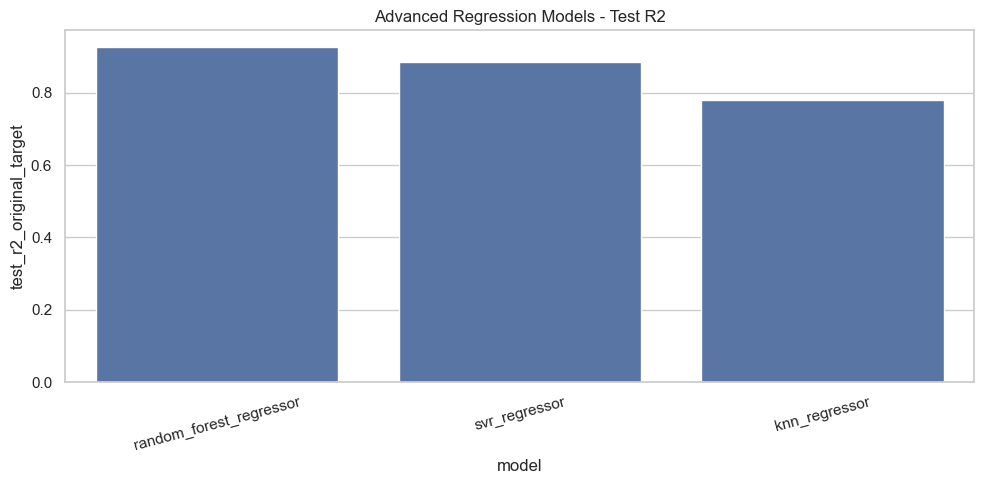

In [9]:
plt.figure(figsize=(10, 5))
sns.barplot(data=regression_results_df, x="model", y="test_r2_original_target")
plt.title("Advanced Regression Models - Test R2")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


## 5. Advanced Classification Models with Grid Search

The classification system uses the same three modeling families. Overall_Rating remains excluded to prevent target leakage.


In [10]:
classification_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
classification_search_spaces = {
    "knn_classifier": {
        "pipeline": Pipeline([("preprocess", build_preprocessor(X_clf)), ("model", KNeighborsClassifier())]),
        "params": {"model__n_neighbors": [3, 5, 9], "model__weights": ["uniform", "distance"], "model__p": [1, 2]},
        "rationale": "KNN assigns a tier from the most similar historical player profiles.",
    },
    "svc_classifier": {
        "pipeline": Pipeline([("preprocess", build_preprocessor(X_clf)), ("model", SVC(random_state=RANDOM_STATE))]),
        "params": {"model__kernel": ["rbf"], "model__C": [1], "model__gamma": ["scale", "auto"]},
        "rationale": "SVC creates nonlinear boundaries between performance tiers.",
    },
    "random_forest_classifier": {
        "pipeline": Pipeline([("preprocess", build_preprocessor(X_clf)), ("model", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))]),
        "params": {"model__n_estimators": [100, 200], "model__max_depth": [None, 10], "model__min_samples_leaf": [1, 3]},
        "rationale": "Random Forest captures nonlinear player development patterns and handles encoded categories well.",
    },
}

best_classification_models = {}
classification_results = []
for name, spec in classification_search_spaces.items():
    print(f"\nTuning {name}...")
    search = GridSearchCV(spec["pipeline"], spec["params"], cv=classification_cv, scoring="accuracy", n_jobs=-1, return_train_score=True)
    search.fit(X_clf_train, y_clf_train)
    best_classification_models[name] = search.best_estimator_
    pred = search.predict(X_clf_test)
    classification_results.append({
        "model": name,
        "best_params": search.best_params_,
        "cv_accuracy": float(search.best_score_),
        "test_accuracy": float(accuracy_score(y_clf_test, pred)),
        "test_precision_weighted": float(precision_score(y_clf_test, pred, average="weighted")),
        "test_recall_weighted": float(recall_score(y_clf_test, pred, average="weighted")),
        "test_f1_weighted": float(f1_score(y_clf_test, pred, average="weighted")),
        "rationale": spec["rationale"],
    })

classification_results_df = pd.DataFrame(classification_results).sort_values("test_accuracy", ascending=False)
classification_results_df



Tuning knn_classifier...

Tuning svc_classifier...

Tuning random_forest_classifier...


,model,best_params,cv_accuracy,test_accuracy,test_precision_weighted,test_recall_weighted,test_f1_weighted,rationale
2,random_forest_classifier,"{'model__max_depth': None, 'model__min_samples...",0.849044,0.849009,0.850442,0.849009,0.849220,Random Forest captures nonlinear player develo...
1,svc_classifier,"{'model__C': 1, 'model__gamma': 'scale', 'mode...",0.838684,0.847992,0.848806,0.847992,0.848161,SVC creates nonlinear boundaries between perfo...
0,knn_classifier,"{'model__n_neighbors': 9, 'model__p': 2, 'mode...",0.817327,0.825623,0.826197,0.825623,0.825884,KNN assigns a tier from the most similar histo...


Best classification model: random_forest_classifier
              precision    recall  f1-score   support

        good       0.83      0.76      0.80       859
    moderate       0.75      0.80      0.77      1021
    verygood       0.94      0.94      0.94       940
        weak       0.88      0.89      0.89      1114

    accuracy                           0.85      3934
   macro avg       0.85      0.85      0.85      3934
weighted avg       0.85      0.85      0.85      3934



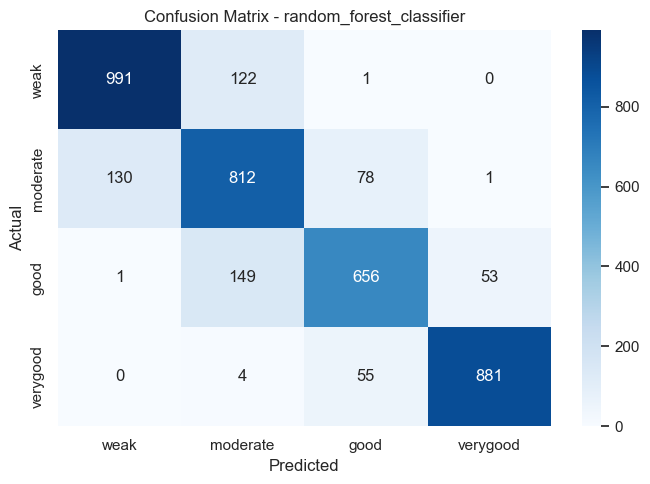

In [11]:
best_clf_name = classification_results_df.iloc[0]["model"]
best_clf = best_classification_models[best_clf_name]
best_clf_pred = best_clf.predict(X_clf_test)

print(f"Best classification model: {best_clf_name}")
print(classification_report(y_clf_test, best_clf_pred))

labels = ["weak", "moderate", "good", "verygood"]
cm = confusion_matrix(y_clf_test, best_clf_pred, labels=labels)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.title(f"Confusion Matrix - {best_clf_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


## 6. Bias and Variance Diagnosis

Learning curves diagnose whether the best models are limited by bias or variance.


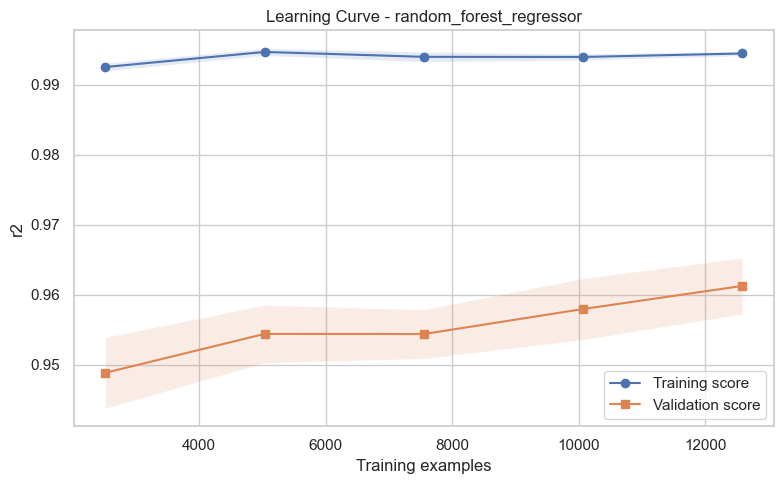

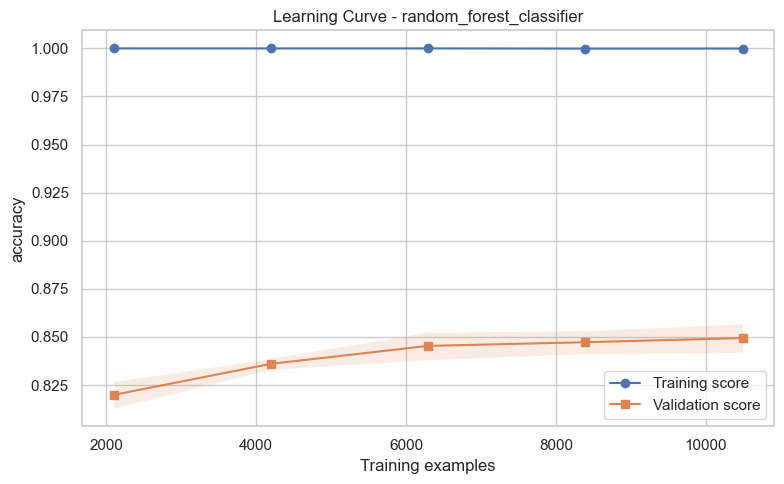

({'final_train_score': 0.9944668719972782,
  'final_validation_score': 0.9612425175571193,
  'gap': 0.03322435444015892,
  'diagnosis': 'acceptable variance'},
 {'final_train_score': 0.9999364352911263,
  'final_validation_score': 0.8494254210843838,
  'gap': 0.1505110142067425,
  'diagnosis': 'high variance risk'})

In [12]:
def plot_learning_curve(estimator, X, y, cv, scoring, title):
    train_sizes, train_scores, valid_scores = learning_curve(
        estimator, X, y, cv=cv, scoring=scoring,
        train_sizes=np.linspace(0.2, 1.0, 5), n_jobs=-1,
    )
    train_mean = train_scores.mean(axis=1)
    valid_mean = valid_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    valid_std = valid_scores.std(axis=1)

    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_mean, marker="o", label="Training score")
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15)
    plt.plot(train_sizes, valid_mean, marker="s", label="Validation score")
    plt.fill_between(train_sizes, valid_mean - valid_std, valid_mean + valid_std, alpha=0.15)
    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel(scoring)
    plt.legend()
    plt.tight_layout()
    plt.show()

    gap = train_mean[-1] - valid_mean[-1]
    diagnosis = "high variance risk" if gap > 0.10 else "acceptable variance"
    if train_mean[-1] < 0.60 and valid_mean[-1] < 0.60:
        diagnosis = "high bias risk"
    return {
        "final_train_score": float(train_mean[-1]),
        "final_validation_score": float(valid_mean[-1]),
        "gap": float(gap),
        "diagnosis": diagnosis,
    }

best_reg_name = regression_results_df.iloc[0]["model"]
best_reg = best_regression_models[best_reg_name]
reg_learning_diagnosis = plot_learning_curve(best_reg, X_reg_train, y_reg_train_log, regression_cv, "r2", f"Learning Curve - {best_reg_name}")
clf_learning_diagnosis = plot_learning_curve(best_clf, X_clf_train, y_clf_train, classification_cv, "accuracy", f"Learning Curve - {best_clf_name}")
reg_learning_diagnosis, clf_learning_diagnosis


## 7. Committee of Models - Ensembling

The final scouting system combines diverse learners. Regression uses averaged predictions, while classification uses soft voting from tuned classifiers.


In [14]:
# Ensemble Classification (Hard Voting)
ensemble_classification = VotingClassifier(
    estimators=[
        ("knn", best_classification_models["knn_classifier"]),
        ("svc", best_classification_models["svc_classifier"]),
        ("rf", best_classification_models["random_forest_classifier"]),
    ],
    voting="hard"
)

# training
ensemble_classification.fit(X_clf_train, y_clf_train)

# prediction
ensemble_clf_pred = ensemble_classification.predict(X_clf_test)

# metrics
ensemble_metrics = {
    "ensemble_classification_accuracy": float(accuracy_score(y_clf_test, ensemble_clf_pred)),
    "ensemble_classification_f1_weighted": float(f1_score(y_clf_test, ensemble_clf_pred, average="weighted")),
}

ensemble_metrics

{'ensemble_classification_accuracy': 0.8528215556685308,
 'ensemble_classification_f1_weighted': 0.853047182058768}

In [17]:
ensemble_regression = VotingRegressor(
    estimators=[
        ("knn", best_regression_models["knn_regressor"]),
        ("svr", best_regression_models["svr_regressor"]),
        ("rf", best_regression_models["random_forest_regressor"]),
    ]
)

# training
ensemble_regression.fit(X_reg_train, y_reg_train_log)

# prediction (inverse log transform)
ensemble_reg_pred = np.expm1(ensemble_regression.predict(X_reg_test))

# metrics
ensemble_metrics = {
    "ensemble_regression_r2": float(r2_score(y_reg_test, ensemble_reg_pred)),
    "ensemble_regression_rmse": float(np.sqrt(mean_squared_error(y_reg_test, ensemble_reg_pred))),
    "ensemble_regression_mae": float(mean_absolute_error(y_reg_test, ensemble_reg_pred)),
}

ensemble_metrics

{'ensemble_regression_r2': 0.8875784771573156,
 'ensemble_regression_rmse': 2.6407795717559703,
 'ensemble_regression_mae': 0.39345296265239765}

In [18]:
 
best_model = best_regression_models["random_forest_regressor"]
 
predicted_values = np.expm1(best_model.predict(X_reg_test))

 
results_df = X_reg_test.copy()

 
results_df["Actual_Value"] = y_reg_test.values
 
results_df["Predicted_Value"] = predicted_values
 
results_df[["Actual_Value", "Predicted_Value"]].head(10)

,Actual_Value,Predicted_Value
15659,0.550,0.436410
1350,21.000,24.454367
4871,0.325,0.349115
16532,1.800,1.772098
385,72.000,55.304093
11930,0.240,0.239548
12888,0.500,0.494778
17390,0.350,0.347605
12233,1.900,1.859644
7466,0.600,0.587374


## 8. Stability Assessment

The cross-validation mean and standard deviation provide statistical evidence that the system is stable across different data subsets.


In [19]:
reg_stability_scores = cross_val_score(ensemble_regression, X_reg, y_reg_log, cv=regression_cv, scoring="r2", n_jobs=-1)
clf_stability_scores = cross_val_score(ensemble_classification, X_clf, y_clf, cv=classification_cv, scoring="accuracy", n_jobs=-1)

cv_stability = {
    "regression_r2": {
        "fold_scores": [float(x) for x in reg_stability_scores],
        "mean": float(np.mean(reg_stability_scores)),
        "std": float(np.std(reg_stability_scores)),
    },
    "classification_accuracy": {
        "fold_scores": [float(x) for x in clf_stability_scores],
        "mean": float(np.mean(clf_stability_scores)),
        "std": float(np.std(clf_stability_scores)),
    },
}
cv_stability


{'regression_r2': {'fold_scores': [0.9727282532799338,
   0.9596157214579946,
   0.9752985162512608,
   0.9494506751372429,
   0.9605296589036024],
  'mean': 0.9635245650060069,
  'std': 0.009440939595743554},
 'classification_accuracy': {'fold_scores': [0.8450274557657108,
   0.8529591214154972,
   0.854462242562929],
  'mean': 0.8508162732480457,
  'std': 0.0041390537709967475}}

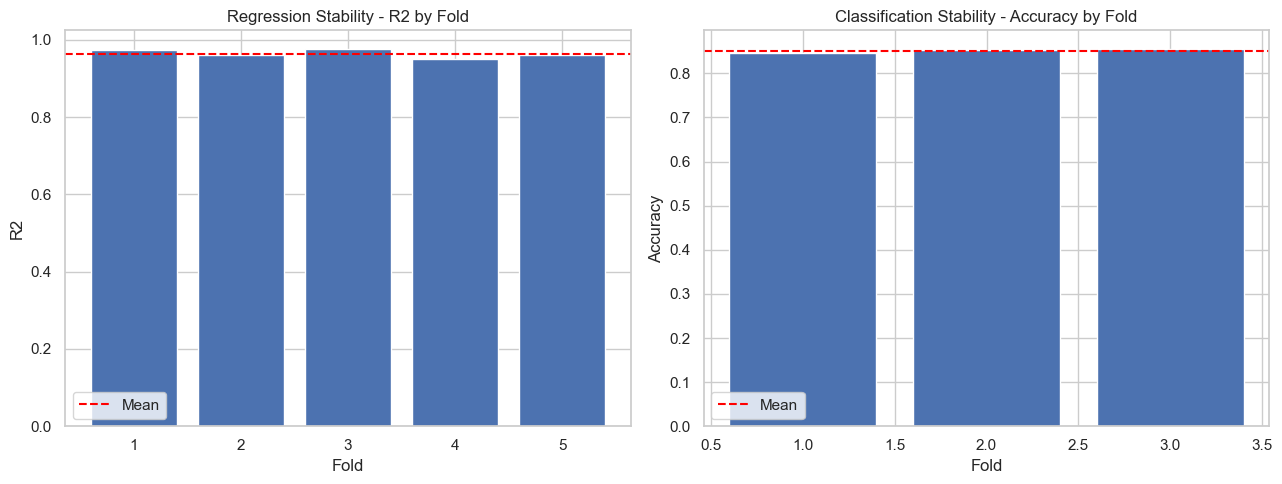

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(range(1, len(reg_stability_scores) + 1), reg_stability_scores)
axes[0].axhline(np.mean(reg_stability_scores), color="red", linestyle="--", label="Mean")
axes[0].set_title("Regression Stability - R2 by Fold")
axes[0].set_xlabel("Fold")
axes[0].set_ylabel("R2")
axes[0].legend()

axes[1].bar(range(1, len(clf_stability_scores) + 1), clf_stability_scores)
axes[1].axhline(np.mean(clf_stability_scores), color="red", linestyle="--", label="Mean")
axes[1].set_title("Classification Stability - Accuracy by Fold")
axes[1].set_xlabel("Fold")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
plt.tight_layout()
plt.show()


## 9. Unified Inference

This function accepts one player profile or a DataFrame of profiles and returns both predicted market value and predicted performance tier using consistent preprocessing.


In [21]:
def unified_scouting_predict(player_profiles):
    if isinstance(player_profiles, pd.Series):
        player_profiles = player_profiles.to_frame().T
    elif isinstance(player_profiles, dict):
        player_profiles = pd.DataFrame([player_profiles])
    else:
        player_profiles = pd.DataFrame(player_profiles).copy()

    reg_input = player_profiles.drop(columns=[regression_target, classification_target], errors="ignore")
    clf_input = player_profiles.drop(columns=[regression_target, classification_target, "Overall_Rating"], errors="ignore")

    predicted_value = np.expm1(ensemble_regression.predict(reg_input))
    predicted_tier = ensemble_classification.predict(clf_input)
    return pd.DataFrame({
        "predicted_value_per_million": predicted_value,
        "predicted_performance_tier": predicted_tier,
    }, index=player_profiles.index)

sample_profiles = data_a3.sample(5, random_state=RANDOM_STATE)
unified_predictions = unified_scouting_predict(sample_profiles)
pd.concat(
    [sample_profiles[["Value Per M$", "Overall_Rating", "Rating_cat"]].reset_index(drop=True),
     unified_predictions.reset_index(drop=True)],
    axis=1,
)


,Value Per M$,Overall_Rating,Rating_cat,predicted_value_per_million,predicted_performance_tier
0,0.550,68,good,0.472370,good
1,21.000,82,verygood,20.735905,verygood
2,0.325,59,moderate,0.396058,weak
3,1.800,68,good,1.812766,good
4,72.000,86,verygood,58.061796,verygood


## 10. Final System Comparison

The advanced system is compared directly with Assignment 2-style baselines.


In [24]:
ensemble_clf_pred_accuracy = accuracy_score(y_clf_test, ensemble_clf_pred)
ensemble_clf_f1 = f1_score(y_clf_test, ensemble_clf_pred, average="weighted")

comparison = pd.DataFrame([
    {
        "system": "Assignment 2 Baseline - Ridge Regression",
        "task": "Regression",
        "primary_metric": "R2",
        "score": baseline_metrics["ridge_regression_r2"],
        "secondary_metric": f"RMSE={baseline_metrics['ridge_regression_rmse']:.4f}",
    },
    {
        "system": "Assignment 3 Ensemble Regression",
        "task": "Regression",
        "primary_metric": "R2",
        "score": ensemble_metrics["ensemble_regression_r2"],
        "secondary_metric": f"RMSE={ensemble_metrics['ensemble_regression_rmse']:.4f}",
    },
    {
        "system": "Assignment 2 Baseline - Logistic Regression",
        "task": "Classification",
        "primary_metric": "Accuracy",
        "score": baseline_metrics["logistic_regression_accuracy"],
        "secondary_metric": f"F1={baseline_metrics['logistic_regression_f1_weighted']:.4f}",
    },
    {
        "system": "Assignment 3 Ensemble Classification",
        "task": "Classification",
        "primary_metric": "Accuracy",
        "score": ensemble_clf_pred_accuracy,
        "secondary_metric": f"F1={ensemble_clf_f1:.4f}",
    },
])

comparison

,system,task,primary_metric,score,secondary_metric
0,Assignment 2 Baseline - Ridge Regression,Regression,R2,0.535003,RMSE=5.3707
1,Assignment 3 Ensemble Regression,Regression,R2,0.887578,RMSE=2.6408
2,Assignment 2 Baseline - Logistic Regression,Classification,Accuracy,0.803762,F1=0.8037
3,Assignment 3 Ensemble Classification,Classification,Accuracy,0.852822,F1=0.8530


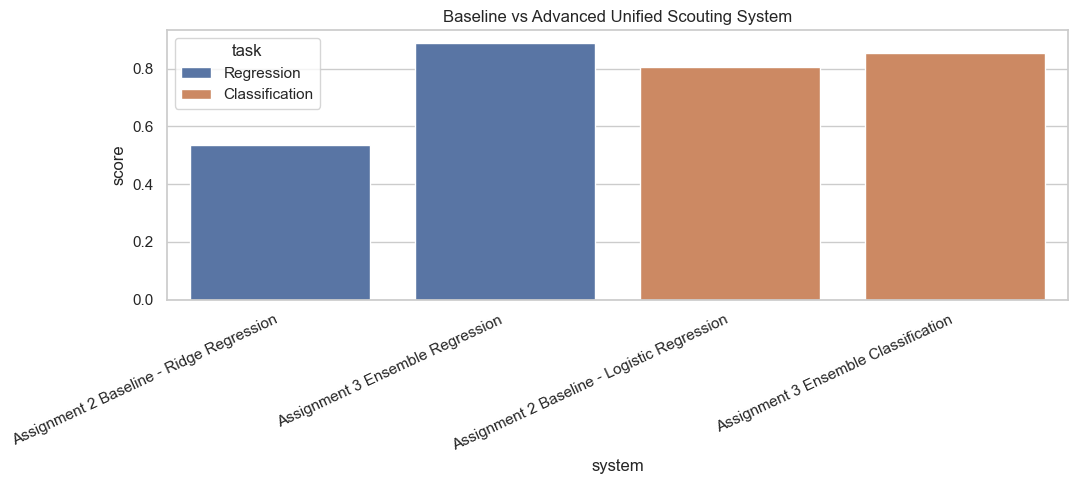

In [25]:
plt.figure(figsize=(11, 5))
sns.barplot(data=comparison, x="system", y="score", hue="task")
plt.title("Baseline vs Advanced Unified Scouting System")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


## 11. Export results.json

Before final submission, replace the placeholder group member names and IDs. Running this cell creates the required JSON artifact.


In [26]:
group_members = [
    {"name": " khaled mohamed gaber", "id": "2403248845"},
    {"name": "joury hfez wahba", "id": "2403247258"},
    {"name": "abdelaziz amr abdelaziz", "id": "2403244565"},
    {"name": "bavly george samuel", "id": "2403241296"},
    {"name": "mariam ehab ahmed", "id": "2403249863"},
]

best_hyperparameters = {
    "regression": {row["model"]: row["best_params"] for _, row in regression_results_df.iterrows()},
    "classification": {row["model"]: row["best_params"] for _, row in classification_results_df.iterrows()},
    "ensemble": {
        "regression": "VotingRegressor using tuned KNN, SVR, and Random Forest regressors",
        "classification": "Soft VotingClassifier using tuned KNN, SVC, and Random Forest classifiers",
    },
}

results = {
    "group_members": group_members,
    "best_hyperparameters": best_hyperparameters,
    "cv_stability": cv_stability,
    "baseline_metrics": baseline_metrics,
    "ensemble_metrics": ensemble_metrics,
    "bias_variance_diagnosis": {
        "regression": reg_learning_diagnosis,
        "classification": clf_learning_diagnosis,
    },
    "comparison_summary": comparison.to_dict(orient="records"),
}

with open("results.json", "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2)

print("results.json exported successfully")
results


results.json exported successfully


{'group_members': [{'name': ' khaled mohamed gaber', 'id': '2403248845'},
  {'name': 'joury hfez wahba', 'id': '2403247258'},
  {'name': 'abdelaziz amr abdelaziz', 'id': '2403244565'},
  {'name': 'bavly george samuel', 'id': '2403241296'},
  {'name': 'mariam ehab ahmed', 'id': '2403249863'}],
 'best_hyperparameters': {'regression': {'random_forest_regressor': {'model__max_depth': None,
    'model__min_samples_leaf': 1,
    'model__n_estimators': 200},
   'svr_regressor': {'model__C': 10,
    'model__epsilon': 0.05,
    'model__gamma': 'scale',
    'model__kernel': 'rbf'},
   'knn_regressor': {'model__n_neighbors': 9,
    'model__p': 1,
    'model__weights': 'uniform'}},
  'classification': {'random_forest_classifier': {'model__max_depth': None,
    'model__min_samples_leaf': 1,
    'model__n_estimators': 200},
   'svc_classifier': {'model__C': 1,
    'model__gamma': 'scale',
    'model__kernel': 'rbf'},
   'knn_classifier': {'model__n_neighbors': 9,
    'model__p': 2,
    'model__weigh

## Final Notes

The final system moves beyond simple baselines by combining instance-based, kernel-based, and tree-based models. Grid search replaces default settings, learning curves diagnose error sources, ensembling creates a committee of models, and cross-validation stability proves that the scouting system remains consistent across different subsets of the data.
